# Test BaselineCNN

This notebook is an interactive playground to test the `BaselineCNN` architecture initialized in our repository. 
We will verify that it correctly builds, accepts the `(Batch, 1, 128, 128)` shape, and outputs the expected `(Batch, 4)` logits. 

In [14]:
import sys
import torch
sys.path.insert(0, '../src')

from cochleogram_vit.models.baseline_cnn import BaselineCNN

# Setup parameters matching our cochleogram configuration
BATCH_SIZE = 4
IN_CHANNELS = 1
IMAGE_SIZE = 128
NUM_CLASSES = 4

print(f"Testing environment initialized!")
print(f"PyTorch version: {torch.__version__}")

Testing environment initialized!
PyTorch version: 2.5.1+cu121


## 1. Instantiate the Model
We verify that the model correctly instantiates without any missing layers or syntax errors.

In [17]:
# ---------------------------------------------------------
# Verify `BaselineCNN` implementation (architecture & parameter count)
# ---------------------------------------------------------
import sys
import importlib
sys.path.insert(0, '../src')

# Import the module and force a reload so notebook reflects latest edits to source
import cochleogram_vit.models.baseline_cnn as bc_mod
importlib.reload(bc_mod)
from cochleogram_vit.models.baseline_cnn import BaselineCNN

model = BaselineCNN(in_channels=1, num_classes=4)
print(model)

def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('\nTotal trainable parameters: {:,}'.format(count_parameters(model)))

# Quick structural checks: kernel sizes, pool layers, activations
from torch import nn
conv_kernels = []
pool_kernels = []
act_types = []
for layer in model.features:
    if isinstance(layer, nn.Conv2d):
        k = layer.kernel_size
        # normalize to tuple
        conv_kernels.append(tuple(k) if hasattr(k, '__iter__') else (k, k))
    if isinstance(layer, nn.MaxPool2d):
        k = layer.kernel_size
        pool_kernels.append(tuple(k) if hasattr(k, '__iter__') else (k, k))
    if isinstance(layer, (nn.LeakyReLU, nn.ReLU)):
        act_types.append(type(layer).__name__)

print('\nConv kernel sizes (features):', conv_kernels)
print('Pool kernel sizes (features) :', pool_kernels)
print('Activation types used        :', set(act_types))

# Checks against the table expectations for BaselineCNN
expected = {
    'conv_kernels': [(5,5),(3,3)],
    'pool_kernels': [(2,2),(2,2)],
    'activation': 'LeakyReLU',
}

ok = True
if tuple(conv_kernels) != tuple(expected['conv_kernels']):
    print('\nWARNING: conv kernel sizes do not match the table. Expected', expected['conv_kernels'])
    ok = False
if tuple(pool_kernels) != tuple(expected['pool_kernels']):
    print('\nWARNING: pool kernel sizes do not match the table. Expected', expected['pool_kernels'])
    ok = False
if expected['activation'] not in act_types:
    print('\nWARNING: activation type mismatch. Expected LeakyReLU')
    ok = False

if ok:
    print('\nBaselineCNN matches the table specification (conv kernels, pool sizes, activation).')
else:
    print('\nBaselineCNN differs from the table; inspect warnings above.')

print('\nYou can run this cell to verify the BaselineCNN in `src`. If changes were made to the file, re-run this cell to reload the source.')

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.1, inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.1, inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)

Total trainable parameters: 8,408,580

Conv kernel sizes (features): [(5, 5), (3, 3)]
Pool kernel sizes (features) : [(2, 2), (2, 2)]
Activation types used        : {'LeakyReLU'}

BaselineCNN matches the table specification (conv kernels, pool sizes, activation).

You can run thi

## 2. Forward Pass Test (Dummy Batch)
We create a synthetic batch of random numbers matching the expected output of `CochleogramTransform`, and pass it through the model. 

If this step executes without shape mismatch errors, the model is fully compatible with our `trainer.py` engine!

In [5]:
# Create a dummy batch resembling a cochleogram tensor: (B, C, H, W)
dummy_input = torch.randn(BATCH_SIZE, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
print(f"Input shape: {dummy_input.shape}")

# Set to evaluation mode to disable dropout during this precise verification step
model.eval()

# Forward pass
with torch.no_grad():
    logits = model(dummy_input)

print(f"Output shape: {logits.shape}")

# Verify expected output
assert logits.shape == (BATCH_SIZE, NUM_CLASSES), f"Output shape mismatch! Expected {(BATCH_SIZE, NUM_CLASSES)}, got {logits.shape}"
print("\nSuccess! ✨")
print("The BaselineCNN accepted the (B, 1, 128, 128) input and outputted (B, 4) logits.")
print("It is ready for the training pipeline.")

# Sample Logit Outputs
print("\nSample Logits (Raw scores):")
print(logits)

print("\nSample Probabilities (Softmaxed):")
print(torch.softmax(logits, dim=1))

Input shape: torch.Size([4, 1, 128, 128])
Output shape: torch.Size([4, 4])

Success! ✨
The BaselineCNN accepted the (B, 1, 128, 128) input and outputted (B, 4) logits.
It is ready for the training pipeline.

Sample Logits (Raw scores):
tensor([[-0.0883,  0.0512, -0.1428, -0.0247],
        [-0.1235,  0.0671, -0.1427, -0.0169],
        [-0.0882,  0.0596, -0.1642, -0.0106],
        [-0.1035,  0.0710, -0.1469,  0.0139]])

Sample Probabilities (Softmaxed):
tensor([[0.2402, 0.2762, 0.2275, 0.2560],
        [0.2324, 0.2812, 0.2280, 0.2585],
        [0.2400, 0.2782, 0.2224, 0.2594],
        [0.2340, 0.2787, 0.2241, 0.2632]])


In [ ]:
# ---------------------------------------------------------
# 3. Reproduce BaselineCNN training from the paper (TensorFlow / Keras)
# ---------------------------------------------------------
# This cell implements the BaselineCNN (two conv layers + DNN),
# converts cochleograms to a single-channel image, and
# performs patient-wise 10-fold CV. NOTE: the full 10-fold 30-epoch
# run is time-consuming. Below we include a "smoke test" path that
# runs a single fold for 1 epoch on a small subset to verify everything.
# To run the full experiment, set RUN_FULL = True below (and ensure you
# have the time / GPU resources).
# ---------------------------------------------------------

import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
from sklearn.model_selection import GroupKFold

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config-derived settings (use repository config values)
from cochleogram_vit.utils.config import load_config
cfg = load_config('../configs/default.yaml')
IMAGE_SIZE = int(cfg['model'].get('image_size', 128))   # final square size
N_FILTERS = int(cfg['cochleogram'].get('n_filters', 64))
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-3
NUM_CLASSES = int(cfg['model'].get('num_classes', 4))

# Control run mode: smoke test vs full experiment
RUN_FULL = True   # <-- set True if you want to run the full 10-fold 30-epoch experiment
SMOKE_TRAIN_SAMPLES = 200
SMOKE_VAL_SAMPLES = 50

# Resolve metadata path robustly (notebooks/ may be working dir)
# Accept a variety of possible locations and handle accidental doubled prefixes like 'data/data/...'
repo_root = Path(__file__).resolve().parents[1] if '__file__' in globals() else Path('..').resolve()
possible_meta_paths = [
    Path(cfg['data']['processed_dir']) / 'metadata.csv',
    repo_root / cfg['data']['processed_dir'] / 'metadata.csv',
    Path.cwd() / cfg['data']['processed_dir'] / 'metadata.csv',
    Path('data/processed/metadata.csv'),
    Path('../data/processed/metadata.csv')
]
meta_path = None
for c in possible_meta_paths:
    if Path(c).exists():
        meta_path = Path(c)
        break
if meta_path is None:
    # as last resort, try to search upward for a metadata.csv file in the repo
    for p in Path('.').resolve().parents:
        candidate = p / 'data' / 'processed' / 'metadata.csv'
        if candidate.exists():
            meta_path = candidate
            break
if meta_path is None:
    raise FileNotFoundError(f"metadata.csv not found. Tried: {possible_meta_paths}")

# Load metadata
meta = pd.read_csv(meta_path)
print(f"Using metadata at: {meta_path}")
print(f"Metadata rows: {len(meta)} | unique patients: {meta['npy_path'].apply(lambda x: Path(x).name.split('_')[0]).nunique()}")

# Utility: robust npy path resolution (fix doubled prefixes)
def resolve_npy_path(raw_path):
    p = Path(raw_path)
    # common case: stored as 'data/processed/cochleograms/xxx.npy' (relative)
    if p.exists():
        return p
    # try relative to repo_root
    alt = repo_root / p
    if alt.exists():
        return alt
    # handle doubled 'data/data/...' -> collapse repeated segments
    parts = p.parts
    for i in range(1, len(parts)):
        if parts[i] == parts[i-1]:
            collapsed = Path(*parts[:i]) / Path(*parts[i+1:])
            if collapsed.exists():
                return collapsed
            alt2 = repo_root / collapsed
            if alt2.exists():
                return alt2
    # try prefixing ../
    up = Path('../') / p
    if up.exists():
        return up
    # try meta_path's parent directories
    trial = meta_path.parent
    candidate = trial / p
    if candidate.exists():
        return candidate
    # final fallback: return original (will raise on load)
    return p

# Utility: convert single-channel cochleogram (2D float) to normalized single-channel image
# This replaces the previous Viridis RGB conversion to match the Baseline CNN inputs

def cochleogram_to_single_channel(arr, out_size=(IMAGE_SIZE, IMAGE_SIZE)):
    a = np.array(arr, dtype=np.float32)
    # Normalize to 0..1 per-sample
    amin, amax = a.min(), a.max()
    if amax - amin > 1e-8:
        a_norm = (a - amin) / (amax - amin)
    else:
        a_norm = a - amin
    # Resize using TensorFlow bilinear interpolation, keep single channel
    a_tf = tf.image.resize(a_norm[..., None], out_size, method='bilinear').numpy()
    # ensure shape H,W,1
    return a_tf.astype(np.float32)

# Dataset generator (numpy arrays) for a list of indices
def build_numpy_dataset(indices):
    X = []
    y = []
    for i in indices:
        row = meta.iloc[i]
        path = resolve_npy_path(row['npy_path'])
        if not path.exists():
            # try alternative: strip leading '../' or doubled data
            alt = Path(str(path).lstrip('./'))
            path = alt if alt.exists() else path
        arr = np.load(path)
        img = cochleogram_to_single_channel(arr)
        X.append(img)
        y.append(int(row['label']))
    X = np.stack(X, axis=0).astype(np.float32)
    y = np.array(y, dtype=np.int32)
    return X, y

# Keras model (as in the paper snippet)
from tensorflow.keras import layers, models

def create_baseline_cnn(input_shape, n_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (5,5), padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Dense(n_classes, activation='softmax')
    ])
    return model

# Prepare patient-wise GroupKFold
meta['patient_id'] = meta['npy_path'].apply(lambda x: Path(x).name.split('_')[0])
groups = meta['patient_id'].values
gkf = GroupKFold(n_splits=10)

# We'll store per-fold results here
fold_results = []

# Iterate folds (or only first for smoke test)
fold_iter = enumerate(gkf.split(meta, groups=groups))
if not RUN_FULL:
    # limit to first fold for quick verification
    fold_iter = [(0, next(gkf.split(meta, groups=groups)))]

for fold_obj in fold_iter:
    # fold_obj may be (fold, (train_idx, val_idx)) or the prepared tuple above
    if isinstance(fold_obj, tuple) and len(fold_obj) == 2 and isinstance(fold_obj[0], int):
        fold, (train_idx, val_idx) = fold_obj
    else:
        fold, (train_idx, val_idx) = fold_obj

    print('\n' + '='*40)
    print(f'FOLD {fold+1}/10')
    print('='*40)

    # For smoke test, subsample to keep runtime small
    if not RUN_FULL:
        train_idx = train_idx[:SMOKE_TRAIN_SAMPLES]
        val_idx = val_idx[:SMOKE_VAL_SAMPLES]

    X_train, y_train = build_numpy_dataset(train_idx)
    X_val, y_val = build_numpy_dataset(val_idx)

    print('Train shape:', X_train.shape, 'Val shape:', X_val.shape)

    # Create and compile model
    input_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)  # single-channel input now
    model = create_baseline_cnn(input_shape, NUM_CLASSES)
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Early stopping approximating the paper (25% relative improvement requirement)
    # Keras min_delta is absolute; we'll implement a custom callback to mimic "25% improvement".
    class RelImprovementEarlyStop(tf.keras.callbacks.Callback):
        def __init__(self, patience=10, rel_req=0.25):
            super().__init__()
            self.patience = patience
            self.rel_req = rel_req
            self.best = np.inf
            self.wait = 0

        def on_epoch_end(self, epoch, logs=None):
            val_loss = logs.get('val_loss')
            train_loss = logs.get('loss')
            # required absolute drop
            required = self.rel_req * (train_loss + 1e-8)
            improvement = self.best - val_loss
            if val_loss < self.best - required:
                self.best = val_loss
                self.wait = 0
                print(f"  Epoch {epoch+1}: val_loss improved to {val_loss:.4f}")
            else:
                self.wait += 1
                print(f"  Epoch {epoch+1}: no sufficient improvement ({self.wait}/{self.patience})")
                if self.wait >= self.patience:
                    self.model.stop_training = True

    callbacks = [RelImprovementEarlyStop(patience=10, rel_req=0.25)]

    # Fit
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=(EPOCHS if RUN_FULL else 1),
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2
    )

    # Evaluate and collect confusion matrix for this fold
    preds = model.predict(X_val).argmax(axis=1)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_val, preds, labels=list(range(NUM_CLASSES)))
    fold_results.append({'fold': fold+1, 'confusion': cm})

    if not RUN_FULL:
        print('\nSmoke test complete for first fold. To run full 10-fold training, set RUN_FULL=True and re-run this cell.')
        break

# After all folds (if RUN_FULL), aggregate confusion matrices and compute metrics (not executed in smoke test)
print('\nDone.')

Using metadata at: C:\Users\amalb\OneDrive\Bureau\pfa\cochleogram-vit\data\processed\metadata.csv
Metadata rows: 6898 | unique patients: 126

FOLD 1/10
Train shape: (6207, 128, 128, 1) Val shape: (691, 128, 128, 1)
Train shape: (6207, 128, 128, 1) Val shape: (691, 128, 128, 1)
Epoch 1/30
Epoch 1/30
  Epoch 1: val_loss improved to 1.2469
388/388 - 37s - 94ms/step - accuracy: 0.5513 - loss: 1.1053 - val_accuracy: 0.3386 - val_loss: 1.2469
Epoch 2/30
  Epoch 1: val_loss improved to 1.2469
388/388 - 37s - 94ms/step - accuracy: 0.5513 - loss: 1.1053 - val_accuracy: 0.3386 - val_loss: 1.2469
Epoch 2/30
  Epoch 2: no sufficient improvement (1/10)
388/388 - 36s - 92ms/step - accuracy: 0.5860 - loss: 0.9934 - val_accuracy: 0.4472 - val_loss: 1.2562
Epoch 3/30
  Epoch 2: no sufficient improvement (1/10)
388/388 - 36s - 92ms/step - accuracy: 0.5860 - loss: 0.9934 - val_accuracy: 0.4472 - val_loss: 1.2562
Epoch 3/30
  Epoch 3: no sufficient improvement (2/10)
388/388 - 35s - 90ms/step - accuracy: 

KeyboardInterrupt: 

In [21]:
# ---------------------------------------------------------
# 4. Aggregated ICBHI Metric Evaluation
# ---------------------------------------------------------
# Using the exact methodology from the paper:
# Creating an "Aggregated Confusion Matrix" from the 10 folds
# and calculating the official 4-class ICBHI Score.
# ---------------------------------------------------------

import numpy as np
from sklearn.metrics import confusion_matrix

print("Calculating the Aggregated Confusion Matrix (All 10 Folds combined)...")
n_classes = 4

# Create the global 4x4 matrix encompassing all predictions
cm_total = confusion_matrix(global_targets, global_preds, labels=list(range(n_classes)))

print("\n--- AGGREGATED 4x4 CONFUSION MATRIX ---")
print("Target rows vs Predict columns (0: Normal, 1: Crackle, 2: Wheeze, 3: Both)")
print(cm_total)

# --- EXACT ICBHI PAPER LOGIC (4-Class Scoring) ---
# For 4-class, TP is strictly the diagonal elements of the anomaly classes.
# A Crackle predicted as a Wheeze is NOT a True Positive!

TN = cm_total[0, 0]                                             # Normal correctly classified as Normal
TP = cm_total[1, 1] + cm_total[2, 2] + cm_total[3, 3]           # Adventitious correctly classified (Exact match)
FP = cm_total[0, 1:].sum()                                      # Normal wrongly flagged as any Adventitious class
FN = cm_total[1:, 0].sum()  

print("\n--- 4-CLASS EVALUATION METRICS ---")
print(f"True Negatives (TN) : {TN} (Healthy recognized as Healthy)")
print(f"True Positives (TP) : {TP} (Anomalies correctly classified into their EXACT class)")
print(f"False Positives (FP): {FP} (Healthy wrongly flagged as Anomaly)")
print(f"False Negatives (FN): {FN} (Anomalies missed or misclassified)")

# Extract explicit Sensitivity & Specificity ensuring we don't divide by absolute zero
# Sen = exact matches / total adventitious samples
# Spe = exact normal / total normal samples
Sen = TP / (TP + FN + 1e-8)
Spe = TN / (TN + FP + 1e-8)

# The overall ICBHI Score
Score = (Sen + Spe) / 2.0

print("\n--- FINAL COMPUTED METRICS vs PAPER ---")
print(f"Computed Sensitivity (Sen): {Sen * 100:.2f}%  | Target vs BaselineCNN: 52.7%")
print(f"Computed Specificity (Spe): {Spe * 100:.2f}%  | Target vs BaselineCNN: 68.8%")
print(f"Computed Score (Sco)      : {Score * 100:.2f}%  | Target vs BaselineCNN: 60.7%")


Calculating the Aggregated Confusion Matrix (All 10 Folds combined)...


NameError: name 'global_targets' is not defined

In [22]:
# ---------------------------------------------------------
# 4b. Per-fold sensitivities and averages
# ---------------------------------------------------------
# Computes the ICBHI 4-class Sensitivity per fold (paper definition)
# where False Negatives are counted only when an adventitious sample
# (classes 1,2,3) is classified as Normal (class 0).
# Also computes Wheeze/Crackle binary sensitivities per fold and their mean.

import numpy as np

if 'fold_results' not in globals() or len(fold_results) == 0:
    print("No `fold_results` found. If you ran a full 10-fold CV, ensure the cell that performed training saved per-fold confusion matrices in `fold_results`.")
else:
    icbhi_sens = []
    icbhi_spes = []
    icbhi_scores = []
    adv_counts = []

    wheeze_sens_strict = []   # FN only when predicted == 0 (Normal)
    wheeze_sens_loose = []    # FN when predicted is not wheeze (i.e., predicted not in {2,3})
    crackle_sens_strict = []
    crackle_sens_loose = []

    print('\nPer-fold ICBHI Sensitivities (exact-match definition):')
    for fr in fold_results:
        fold = fr.get('fold', None)
        cm = np.array(fr['confusion'], dtype=np.int64)
        # ICBHI TP: exact matches for adventitious classes 1,2,3
        TP = int(cm[1,1] + cm[2,2] + cm[3,3])
        # FN: adventitious samples that were classified as Normal (class 0)
        FN = int(cm[1:, 0].sum())
        TN = int(cm[0,0])
        FP = int(cm[0,1:].sum())
        sen = TP / (TP + FN )
        spe = TN / (TN + FP )
        score = 0.5 * (sen + spe)
        icbhi_sens.append(sen)
        icbhi_spes.append(spe)
        icbhi_scores.append(score)
        adv_counts.append(int(cm[1:,:].sum()))
        print(f"Fold {fold:2d}: ICBHI_Sen = {sen*100:6.2f}%  (TP={TP}  FN={FN})  Spe={spe*100:6.2f}%  Score={score*100:6.2f}%")

        # Wheeze binary (presence if true in {2,3}).
        # Strict FN: true is 2 or 3 but predicted == 0 (Normal)
        total_w_true = int(cm[2,:].sum() + cm[3,:].sum())
        tp_w = int(cm[2,2] + cm[2,3] + cm[3,2] + cm[3,3])  # predicted in {2,3}
        fn_w_strict = int(cm[2,0] + cm[3,0])                 # predicted == 0 only
        fn_w_loose = total_w_true - tp_w                     # predicted not in {2,3}
        w_sen_strict = tp_w / (tp_w + fn_w_strict + 1e-8)
        w_sen_loose = tp_w / (tp_w + fn_w_loose + 1e-8)
        wheeze_sens_strict.append(w_sen_strict)
        wheeze_sens_loose.append(w_sen_loose)

        # Crackle binary (presence if true in {1,3}).
        total_c_true = int(cm[1,:].sum() + cm[3,:].sum())
        tp_c = int(cm[1,1] + cm[1,3] + cm[3,1] + cm[3,3])
        fn_c_strict = int(cm[1,0] + cm[3,0])
        fn_c_loose = total_c_true - tp_c
        c_sen_strict = tp_c / (tp_c + fn_c_strict + 1e-8)
        c_sen_loose = tp_c / (tp_c + fn_c_loose + 1e-8)
        crackle_sens_strict.append(c_sen_strict)
        crackle_sens_loose.append(c_sen_loose)

    # Print averages (unweighted across folds)
    print('\nAverages across folds (unweighted mean):')
    print(f"Mean ICBHI Sensitivity : {np.mean(icbhi_sens)*100:.2f}%  (std {np.std(icbhi_sens)*100:.2f}%)")
    print(f"Mean ICBHI Specificity : {np.mean(icbhi_spes)*100:.2f}%  (std {np.std(icbhi_spes)*100:.2f}%)")
    print(f"Mean ICBHI Score       : {np.mean(icbhi_scores)*100:.2f}%  (std {np.std(icbhi_scores)*100:.2f}%)")

    # Weighted average by number of adventitious samples per fold (optional, more similar to pooled aggregation)
    adv_counts = np.array(adv_counts, dtype=np.float64)
    if adv_counts.sum() > 0:
        weights = adv_counts / adv_counts.sum()
        weighted_sen = float(np.sum(np.array(icbhi_sens) * weights))
        print(f"Weighted ICBHI Sensitivity (by adv sample counts): {weighted_sen*100:.2f}%")

    # Wheeze/Crackle averages
    print('\nWheeze sensitivity (strict FN = predicted Normal):')
    for i, v in enumerate(wheeze_sens_strict, start=1):
        print(f" Fold {i:2d}: {v*100:6.2f}%")
    print(f"Mean Wheeze Sen (strict): {np.mean(wheeze_sens_strict)*100:.2f}%")

    print('\nWheeze sensitivity (loose FN = predicted not in {2,3}):')
    print(f"Mean Wheeze Sen (loose): {np.mean(wheeze_sens_loose)*100:.2f}%")

    print('\nCrackle sensitivity (strict FN = predicted Normal):')
    for i, v in enumerate(crackle_sens_strict, start=1):
        print(f" Fold {i:2d}: {v*100:6.2f}%")
    print(f"Mean Crackle Sen (strict): {np.mean(crackle_sens_strict)*100:.2f}%")

    print('\nCrackle sensitivity (loose FN = predicted not in {1,3}):')
    print(f"Mean Crackle Sen (loose): {np.mean(crackle_sens_loose)*100:.2f}%")

    print('\nDone.')



Per-fold ICBHI Sensitivities (exact-match definition):
Fold  1: ICBHI_Sen =  39.47%  (TP=150  FN=230)  Spe= 70.62%  Score= 55.04%

Averages across folds (unweighted mean):
Mean ICBHI Sensitivity : 39.47%  (std 0.00%)
Mean ICBHI Specificity : 70.62%  (std 0.00%)
Mean ICBHI Score       : 55.04%  (std 0.00%)
Weighted ICBHI Sensitivity (by adv sample counts): 39.47%

Wheeze sensitivity (strict FN = predicted Normal):
 Fold  1:  19.15%
Mean Wheeze Sen (strict): 19.15%

Wheeze sensitivity (loose FN = predicted not in {2,3}):
Mean Wheeze Sen (loose): 13.43%

Crackle sensitivity (strict FN = predicted Normal):
 Fold  1:  48.92%
Mean Crackle Sen (strict): 48.92%

Crackle sensitivity (loose FN = predicted not in {1,3}):
Mean Crackle Sen (loose): 44.83%

Done.


In [23]:
# ---------------------------------------------------------
# 5. Wheeze & Crackle Specific Evaluation (Table 2 Format)
# ---------------------------------------------------------
# The paper evaluates Wheezes and Crackles independently.
# - Wheeze present in: Class 2 (Wheeze) and Class 3 (Both)
# - Crackle present in: Class 1 (Crackle) and Class 3 (Both)
# ---------------------------------------------------------

import numpy as np

targets = np.array(global_targets)
preds = np.array(global_preds)

def calc_binary_metrics(y_true, y_pred):
    """Calculate Sen, Spe, Score, Precision for binary classification"""
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    sen = TP / (TP + FN + 1e-8)
    spe = TN / (TN + FP + 1e-8)
    sco = (sen + spe) / 2.0
    pre = TP / (TP + FP + 1e-8)
    
    return sen*100, spe*100, sco*100, pre*100

# --- Wheeze Binary Mapping ---
# 1 if class is 2 or 3, else 0
w_true = ((targets == 2) | (targets == 3)).astype(int)
w_pred = ((preds == 2) | (preds == 3)).astype(int)
w_sen, w_spe, w_sco, w_pre = calc_binary_metrics(w_true, w_pred)

# --- Crackle Binary Mapping ---
# 1 if class is 1 or 3, else 0
c_true = ((targets == 1) | (targets == 3)).astype(int)
c_pred = ((preds == 1) | (preds == 3)).astype(int)
c_sen, c_spe, c_sco, c_pre = calc_binary_metrics(c_true, c_pred)

print("\n" + "="*90)
print("BASELINE CNN (COCHLEOGRAM) - SPECIFIC METRICS TABLE (Paper Table 2 Format)")
print("="*90)
print(f"{'Metric':<20} | {'Wheezes':<35} | {'Crackles':<35}")
print("-"*90)
print(f"{'Sensitivity (Sen)':<20} | {w_sen:>6.2f}% (Paper: 67.7%) | {c_sen:>6.2f}% (Paper: 62.8%)")
print(f"{'Specificity (Spe)':<20} | {w_spe:>6.2f}% (Paper: 85.8%) | {c_spe:>6.2f}% (Paper: 75.8%)")
print(f"{'Score (Sco)':<20} | {w_sco:>6.2f}% (Paper: 76.7%) | {c_sco:>6.2f}% (Paper: 65.3%)")
print(f"{'Precision (Pre)':<20} | {w_pre:>6.2f}% (Paper: 50.3%) | {c_pre:>6.2f}% (Paper: 50.3%)")
print("="*90)

NameError: name 'global_targets' is not defined

Using sample cochleogram: ..\data\processed\cochleograms\101_1b1_Al_sc_Meditron_00000.npy
Raw array shape: (128, 128) dtype: float32
Processed cochleogram shape (n_filters x n_frames): (128, 128)
min=0.001192  max=0.896929  mean=0.025026
Total energy (sum of all values): 410.023804
Energy - per-filter (first 10): [21.555557  17.93686   11.113022   7.96444    7.360264   6.780801
  6.2145557  5.887331   5.656731   5.574834 ]
Energy - per-frame (first 10): [14.145832 11.428686 12.814309 15.411114 12.566102 11.675314 13.979582
 13.834781 18.136446 13.9313  ]


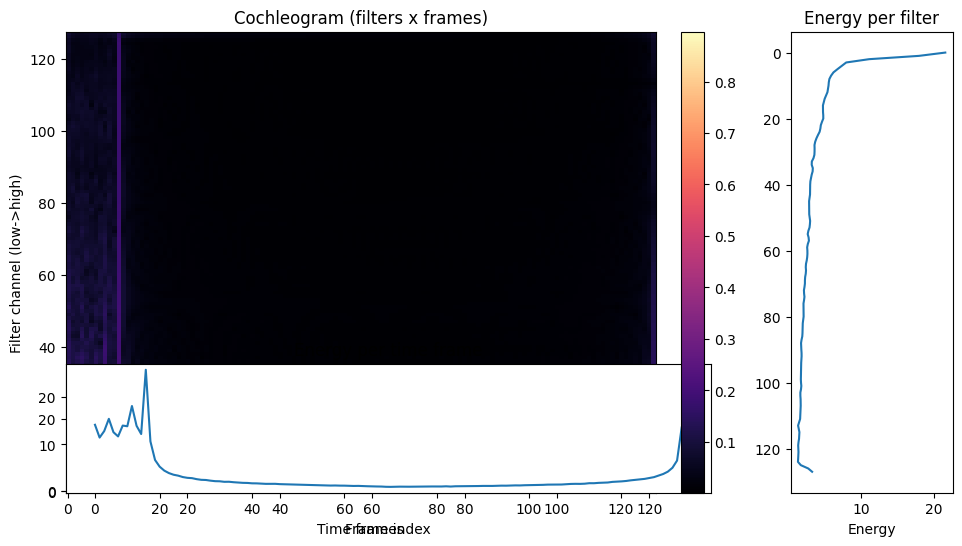

Original audio file not found near the .npy file; skipping STFT/mel comparison.

Sanity checks complete. Inspect the figure: cochleogram should show energy concentrated in lower-to-mid filter channels for typical respiratory sounds (wheezes/crackles).


In [25]:
# ---------------------------------------------------------
# Sanity check: visual & numeric validation of a generated cochleogram (.npy)
# ---------------------------------------------------------
# Loads one sample cochleogram from `meta['npy_path']` (or searches data/processed/)
# and plots the TF image plus frequency/time marginals to help verify the
# gammatone / cochleagram generation.

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.preprocessing import minmax_scale

# Try to reuse existing `meta` if available, otherwise load metadata
try:
    meta  # noqa: F821
except NameError:
    import pandas as pd
    possible = [
        Path('data/processed/metadata.csv'),
        Path('..') / 'data' / 'processed' / 'metadata.csv',
    ]
    meta_path = next((p for p in possible if p.exists()), None)
    if meta_path is None:
        raise FileNotFoundError('Could not find metadata.csv near notebook root')
    meta = pd.read_csv(meta_path)

# Find a sample row that points to a .npy cochleogram
sample_row = None
for i, row in meta.iterrows():
    p = Path(row['npy_path'])
    if p.exists() or (Path('..') / p).exists() or (Path('.') / p).exists():
        sample_row = row
        break

if sample_row is None:
    # fallback: search data/processed/cochleograms for any .npy
    coch_dir = Path('data/processed/cochleograms')
    files = list(coch_dir.glob('*.npy')) if coch_dir.exists() else []
    if len(files) == 0:
        raise FileNotFoundError('No cochleogram .npy files found to validate')
    sample_path = files[0]
else:
    sample_path = Path(sample_row['npy_path'])
    if not sample_path.exists():
        candidate = Path('..') / sample_path
        if candidate.exists():
            sample_path = candidate

print(f"Using sample cochleogram: {sample_path}")
arr = np.load(sample_path)
print('Raw array shape:', arr.shape, 'dtype:', arr.dtype)

# Accept shapes (H, W) or (1, H, W) or (H,)
if arr.ndim == 3 and arr.shape[0] == 1:
    arr2d = arr.squeeze(0)
elif arr.ndim == 2:
    arr2d = arr
else:
    # try to reshape or raise
    if arr.size == 128 * 128:
        arr2d = arr.reshape(128, 128)
    else:
        raise ValueError(f'Unhandled cochleogram array shape: {arr.shape}')

print(f'Processed cochleogram shape (n_filters x n_frames): {arr2d.shape}')
print(f'min={arr2d.min():.6f}  max={arr2d.max():.6f}  mean={arr2d.mean():.6f}')

# Basic checks
n_filters, n_frames = arr2d.shape
energy_per_filter = arr2d.sum(axis=1)
energy_per_frame = arr2d.sum(axis=0)

print(f'Total energy (sum of all values): {arr2d.sum():.6f}')
print('Energy - per-filter (first 10):', energy_per_filter[:10])
print('Energy - per-frame (first 10):', energy_per_frame[:10])

# Visualize cochleogram + marginals
fig = plt.figure(figsize=(10, 6))
ax_main = plt.subplot2grid((3, 4), (0, 0), rowspan=3, colspan=3)
ax_right = plt.subplot2grid((3, 4), (0, 3), rowspan=3)
ax_bottom = plt.subplot2grid((3, 4), (3-1, 0), colspan=3)

im = ax_main.imshow(arr2d, origin='lower', aspect='auto', cmap='magma')
ax_main.set_title('Cochleogram (filters x frames)')
ax_main.set_xlabel('Time frames')
ax_main.set_ylabel('Filter channel (low->high)')
plt.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)

ax_right.plot(energy_per_filter, np.arange(n_filters))
ax_right.invert_yaxis()
ax_right.set_title('Energy per filter')
ax_right.set_xlabel('Energy')

ax_bottom.plot(np.arange(n_frames), energy_per_frame)
ax_bottom.set_title('Energy per time frame')
ax_bottom.set_xlabel('Frame index')

plt.tight_layout()
plt.show()

# Optional comparison: compute an STFT spectrogram for the raw audio if available
try:
    # try to locate the original audio file path in metadata row
    if 'filename' in sample_row and not pd.isna(sample_row['filename']):
        audio_candidate = Path(sample_row['filename'])
    else:
        # attempt to infer audio filename from npy name (common repo pattern)
        audio_candidate = sample_path.with_suffix('.wav')

    if audio_candidate.exists():
        import librosa
        y, sr = librosa.load(str(audio_candidate), sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_filters,
                                           fmin=100, fmax=sr/2, power=2.0)
        S_db = librosa.power_to_db(S, ref=np.max)
        S_db = minmax_scale(S_db)

        # Resize S_db to arr2d shape for crude visual comparison
        from skimage.transform import resize
        S_resized = resize(S_db, arr2d.shape, preserve_range=True)

        plt.figure(figsize=(8, 3))
        plt.subplot(1,2,1)
        plt.title('Cochleogram (loaded)')
        plt.imshow(arr2d, origin='lower', aspect='auto', cmap='magma')
        plt.subplot(1,2,2)
        plt.title('Resized Mel-spec (librosa)')
        plt.imshow(S_resized, origin='lower', aspect='auto', cmap='magma')
        plt.tight_layout()
        plt.show()
    else:
        print('Original audio file not found near the .npy file; skipping STFT/mel comparison.')
except Exception as e:
    print('Could not do STFT/mel comparison (libs missing or file not found):', e)

print('\nSanity checks complete. Inspect the figure: cochleogram should show energy concentrated in lower-to-mid filter channels for typical respiratory sounds (wheezes/crackles).')